In [98]:
import numpy as np
import matplotlib.pyplot as plt

In [99]:
class TestStencil:
    def __init__(self,step_size,start_vector):
        self.step_size = step_size
        self.start_vector = np.genfromtxt(start_vector) # shape: (Nz,1+Nt)
        self.nparams = len(self.start_vector)
    
    def five_points_stencil_points(self, param_index):
        delta = np.zeros(self.nparams) # (Nt*Nz,)
        delta[param_index] = 1.0
        points = [self.start_vector + x*delta for x in
                  [
                      +2*self.step_size, # forward far
                      +1*self.step_size, # forward near
                      -1*self.step_size, # backward near 
                      -2*self.step_size  # backward far
                  ]
                 ] # (4, Nt*Nz)
        return points

    def generate_sample_points(self):
        points = []
        for p in range(self.nparams):
            points += self.five_points_stencil_points(p)
        return points
    
    func_constant = lambda self, point: np.ones(len(point))
    func_linear = lambda self, point: point
    func_quadratic = lambda self, point: point**2
    func_cubic = lambda self, point: point**3
    func_polynomial = lambda self, point,n: point**n
    func_sin = lambda self, point: np.sin(point) 
    func_cos = lambda self, point: np.cos(point) 
    
    def compute_obs(self,func):
        observable = []
        points = self.generate_sample_points()
        for point in points:
            obs = func(point)
            observable.append(obs) 
        return observable

    def five_point_stencil_deriv(self, obs):
        deriv = (-obs[0] + 8*obs[1] - 8*obs[2] + obs[3]) / (12*self.step_size)
        return deriv

    def extract_derivatives(self, results):
        derivatives = []
        for p in range(self.nparams):
            results_p = results[4*p:4*(p+1)]
            derivative = self.five_point_stencil_deriv(results_p)
            derivatives.append(derivative)
        return np.array(derivatives)
    
    def test(self,func):
        results = self.compute_obs(func)
        derivatives = self.extract_derivatives(results)
        return derivatives

In [100]:
step_size=0.1
x = np.linspace(-1,1,100)
np.savetxt('start_vector.txt',x)
start_vector = 'start_vector.txt'

stencil_obj = TestStencil(step_size=step_size,start_vector=start_vector)

####
y_obj_constant = stencil_obj.func_constant
y_constant = y_obj_constant(x)
yprime_constant = stencil_obj.test(y_obj_constant)

y_obj_linear = stencil_obj.func_linear
y_linear = y_obj_linear(x)
yprime_linear = stencil_obj.test(y_obj_linear)

y_obj_quadratic = stencil_obj.func_quadratic
y_quadratic = y_obj_quadratic(x)
yprime_quadratic = stencil_obj.test(y_obj_quadratic)

y_obj_cubic = stencil_obj.func_cubic
y_cubic = y_obj_cubic(x)
yprime_cubic = stencil_obj.test(y_obj_cubic)

y_obj_sin = stencil_obj.func_sin
y_sin = y_obj_sin(x)
yprime_sin = stencil_obj.test(y_obj_sin)

y_obj_cos = stencil_obj.func_cos
y_cos = y_obj_cos(x)
yprime_cos = stencil_obj.test(y_obj_cos)

In [101]:
yprime_constant = [yprime_constant[i,j] for i in range(len(x)) for j in range(len(x)) if i==j]
yprime_linear = [yprime_linear[i,j] for i in range(len(x)) for j in range(len(x)) if i==j]
yprime_quadratic = [yprime_quadratic[i,j] for i in range(len(x)) for j in range(len(x)) if i==j]
yprime_cubic = [yprime_cubic[i,j] for i in range(len(x)) for j in range(len(x)) if i==j]
yprime_sin = [yprime_sin[i,j] for i in range(len(x)) for j in range(len(x)) if i==j]
yprime_cos = [yprime_cos[i,j] for i in range(len(x)) for j in range(len(x)) if i==j]
ys = [y_constant,y_linear,y_quadratic,y_cubic,y_sin,y_cos]
yprimes = [yprime_constant,yprime_linear,yprime_quadratic,yprime_cubic,yprime_sin,yprime_cos]
labels = ['constant', 'linear', 'quadratic','cubic','sin','cos']
ijs = [(i,j) for j in range(2) for i in range(3)]

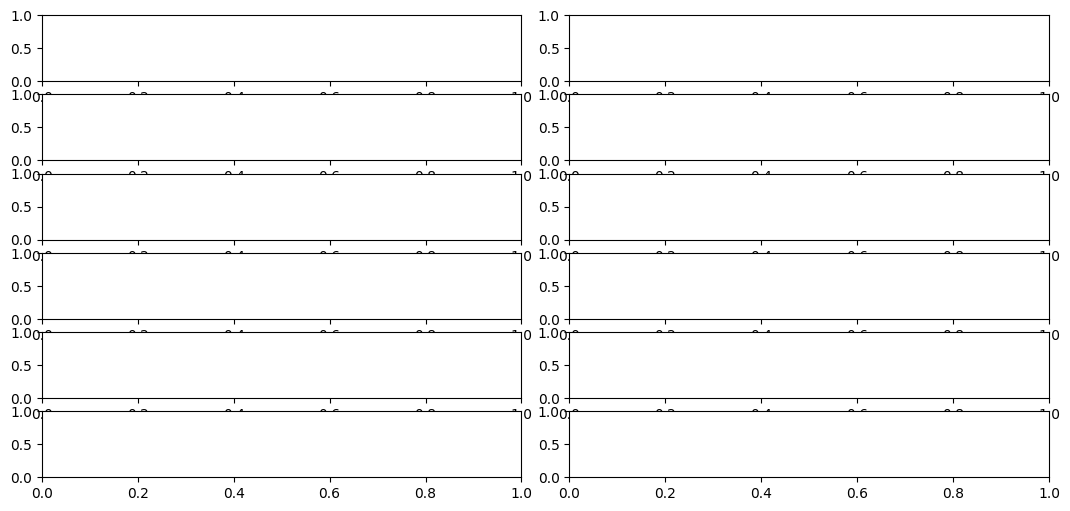

In [58]:
fig, axes = plt.subplots(nrows=6, ncols=2, sharex=False, sharey=False,figsize=(13, 6),
                        gridspec_kw={'wspace':0.1, 'hspace':0.2})

# for k,ij in enumerate(ijs):
#     axes[ij[0],ij[1]].plot(x,ys[k],'k',label=f'func: {labels[k]}')
#     axes[ij[0],ij[1]].plot(x,yprimes[k],label='derivative')
#     axes[ij[0],ij[1]].legend(loc='best')
# axes[0,0].plot(x,ys[0],'k',label=f'func: {labels[0]}')
# axes[0,0].plot(x,yprimes[0],label='derivative')
# axes[0,0].legend(loc='best')

# For column 0
axes[1, 0].sharex(axes[0, 0])
axes[3, 0].sharex(axes[2, 0])
axes[5, 0].sharex(axes[4, 0])

# For column 1
axes[1, 1].sharex(axes[0, 1])
axes[3, 1].sharex(axes[2, 1])
axes[5, 1].sharex(axes[4, 1])

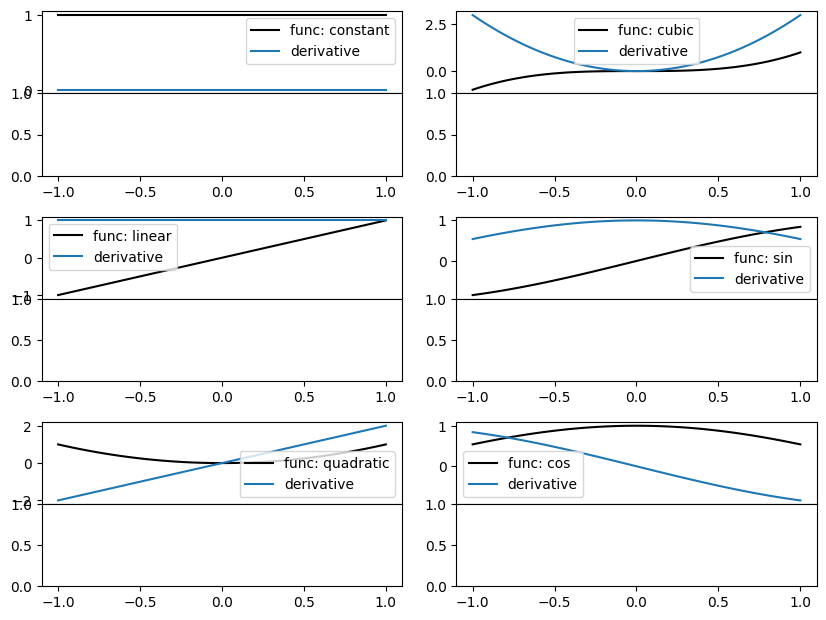

In [107]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 8))

# Create a GridSpec with extra height for gaps between groups
gs = gridspec.GridSpec(nrows=9, ncols=2, height_ratios=[1,1, 0.5, 1,1, 0.5, 1,1, 0.5], hspace=0.0, wspace=0.15)

# Column 0 axes
ax00 = fig.add_subplot(gs[0, 0])
ax10 = fig.add_subplot(gs[1, 0], sharex=ax00)

ax20 = fig.add_subplot(gs[3, 0])
ax30 = fig.add_subplot(gs[4, 0], sharex=ax20)

ax40 = fig.add_subplot(gs[6, 0])
ax50 = fig.add_subplot(gs[7, 0], sharex=ax40)

# Column 1 axes
ax01 = fig.add_subplot(gs[0, 1])
ax11 = fig.add_subplot(gs[1, 1], sharex=ax01)

ax21 = fig.add_subplot(gs[3, 1])
ax31 = fig.add_subplot(gs[4, 1], sharex=ax21)

ax41 = fig.add_subplot(gs[6, 1])
ax51 = fig.add_subplot(gs[7, 1], sharex=ax41)

axs = []

k=0
ax00.plot(x,ys[k],'k',label=f'func: {labels[k]}')
ax00.plot(x,yprimes[k],label='derivative')
ax00.legend(loc='best')
k=1
ax20.plot(x,ys[k],'k',label=f'func: {labels[k]}')
ax20.plot(x,yprimes[k],label='derivative')
ax20.legend(loc='best')
k=2
ax40.plot(x,ys[k],'k',label=f'func: {labels[k]}')
ax40.plot(x,yprimes[k],label='derivative')
ax40.legend(loc='best')
k=3
ax01.plot(x,ys[k],'k',label=f'func: {labels[k]}')
ax01.plot(x,yprimes[k],label='derivative')
ax01.legend(loc='best')
k=4
ax21.plot(x,ys[k],'k',label=f'func: {labels[k]}')
ax21.plot(x,yprimes[k],label='derivative')
ax21.legend(loc='best')
k=5
ax41.plot(x,ys[k],'k',label=f'func: {labels[k]}')
ax41.plot(x,yprimes[k],label='derivative')
ax41.legend(loc='best')

# (Optional) Hide redundant x-axis tick labels
for ax in [ax00, ax20, ax40, ax01, ax21, ax41]:
    ax.tick_params(labelbottom=False)


In [4]:
# start_vector = np.array(
#     [
#         [1,6,11 ],
#         [2,7,12],
#         [3,8,13],
#         [4,9,14],
#         [5,10,15]
#     ])
start_vector = np.array(
    [
        [1,6,11 ],
        [2,7,12],
        [3,8,13],
    ])
Nz,Nt = start_vector.shape

In [ ]:
start_vector = start_vector.T.flatten()

nparams = len(start_vector)
step_size = .1

def five_points_stencil_points(param_index):
    delta = np.zeros(nparams) 
    delta[param_index] = 1.0
    points = [start_vector + x*delta for x in 
                [2*step_size, 
                 1*step_size, 
                -1*step_size,
                -2*step_size]] 
    return points

In [6]:
def generate_sample_points():
    points = []
    for p in range(nparams):
        points += five_points_stencil_points(p)
    return points

In [ ]:
points=generate_sample_points()
# points[0].reshape(3,5).T
# for i,point in enumerate(points):
#     x  = point.reshape(Nt,Nz).T
#     print(i,x,x.shape)
#     print()
np.array(points).shape

In [ ]:
for p in range(nparams):
    x = np.array(five_points_stencil_points(p))
    y = x.reshape(4,Nt,Nz).transpose(0,2,1)
    print(p,y)
    print()

y.shape

In [ ]:
obs=[]
for i in range(4):
    xip = np.array([i,i,i])
    xim = np.array([i,i,i])
    xipm = np.hstack((xip,xim))
    obs.append(xipm)
obs

In [26]:
step_size=0.01
def five_point_stencil_deriv(obs):
    deriv = (-obs[0] + 8*obs[1] - 8*obs[2] + obs[3]) / (12*step_size)
    return deriv

In [ ]:
nparams

In [ ]:
def extract_derivatives(results):
    derivatives = []
    for p in range(nparams):
        results_p = results[4*p:4*(p+1)]
        derivative = five_point_stencil_deriv(results_p)
        derivatives.append(derivative)
    return np.array(derivatives)

